# Chapter 1 — Orientation

This notebook accompanies **Chapter 1** of *Inference in Statistical Modelling and Machine Learning*.

---

### How to use this notebook

A Jupyter notebook is made of *cells*. Each cell is either text (like this one) or code (like the grey boxes below).  
To run a code cell, click on it and press **Shift + Enter**. The output appears directly underneath.  
Run cells from top to bottom — later cells often depend on earlier ones.

---

### Libraries we'll use

Almost every notebook in this series will import the same two libraries. Run the cell below first.

In [1]:
import numpy as np                  # fast numerical arrays and maths
import matplotlib.pyplot as plt     # plotting

rng = np.random.default_rng(42)     # a random-number generator with a fixed seed for reproducibility

---
## The curse of dimensionality

Section 1.3 introduces *dimensionality reduction* and mentions, almost in passing, a deeply unsettling fact about high-dimensional spaces.  Exercise 1.5 asks you to think about it carefully.  Here we explore it visually.

**The setup.** Scatter 100 points at random inside the unit square $[0,1]^2$.  Pick any two — they'll be at some distance from each other, and that distance will vary quite a bit.  Now do the same thing in a 100-dimensional hypercube.  Something strange happens.

Let's look.

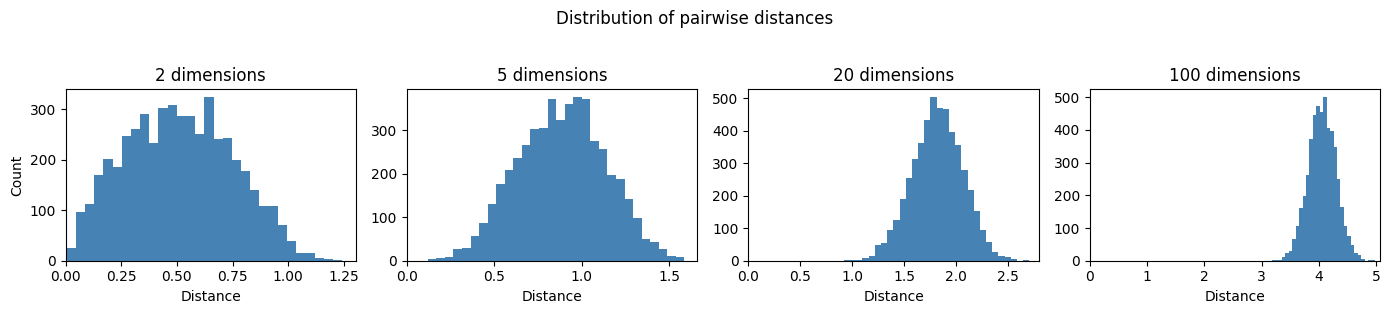

In [2]:
def pairwise_distances(points):
    """Return all pairwise Euclidean distances between rows of `points`."""
    n = len(points)
    dists = []
    for i in range(n):
        for j in range(i + 1, n):
            diff = points[i] - points[j]
            dists.append(np.sqrt((diff ** 2).sum()))
    return np.array(dists)

n_points    = 100
dims_to_try = [2, 5, 20, 100]

fig, axes = plt.subplots(1, len(dims_to_try), figsize=(14, 3), sharey=False)

for ax, d in zip(axes, dims_to_try):
    points = rng.uniform(0, 1, size=(n_points, d))
    dists  = pairwise_distances(points)
    ax.hist(dists, bins=30, color='steelblue', edgecolor='none')
    ax.set_xlim(left=0)
    ax.set_title(f'{d} dimensions')
    ax.set_xlabel('Distance')

axes[0].set_ylabel('Count')
plt.suptitle('Distribution of pairwise distances', y=1.03, fontsize=12)
plt.tight_layout()
plt.show()

In 2 dimensions the distances spread widely — some pairs of points are close, others far apart.  By 100 dimensions the distribution has collapsed into a narrow spike near the middle of the axis.  Almost every pair of points is roughly the same distance apart.

We can summarise this by plotting the ratio of the *largest* to the *smallest* pairwise distance.

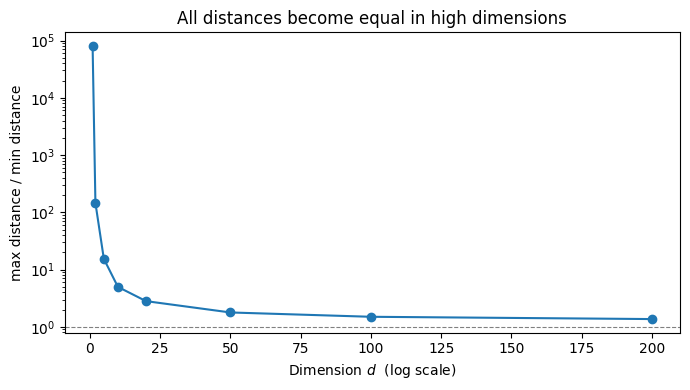

In [3]:
all_dims = [1, 2, 5, 10, 20, 50, 100, 200]
ratios   = []

for d in all_dims:
    points = rng.uniform(0, 1, size=(n_points, d))
    dists  = pairwise_distances(points)
    ratios.append(dists.max() / dists.min())

plt.figure(figsize=(7, 4))
plt.plot(all_dims, ratios, 'o-')
plt.yscale('log')
plt.axhline(1, color='grey', linestyle='--', linewidth=0.8)
plt.xlabel('Dimension $d$  (log scale)')
plt.ylabel('max distance / min distance')
plt.title('All distances become equal in high dimensions')
plt.tight_layout()
plt.show()

The ratio falls toward 1.  In very high dimensions there is no meaningful distinction between a *near* neighbour and a *far* one — the geometry we rely on in everyday life simply breaks down.

> **Book link — Exercise 1.5.** The exercise asks you to show analytically *why* this happens.  Each squared-distance component $W_j = (U_j - V_j)^2$ is an independent random variable with the same mean and variance.  Summing $d$ of them, the mean grows as $d$ but the standard deviation grows only as $\sqrt{d}$, so the spread *relative to the mean* shrinks as $1/\sqrt{d} \to 0$.

---
## Two blobs: when the curse matters in practice

The curse of dimensionality is not just a curiosity — it can completely destroy our ability to tell two groups of points apart.

**Setup.** Create two groups of 100 points in $d$ dimensions:

- **Blob A**: first coordinate $x_0 = 0$, all others uniform on $[0, 1]$
- **Blob B**: first coordinate $x_0 = 1$, all others uniform on $[0, 1]$

In low dimensions $x_0$ dominates the distance — the blobs are easily separated.  As $d$ grows, the other coordinates swamp the signal in $x_0$ and the blobs become indistinguishable.

We'll measure this by asking: for each point in Blob A, what fraction of its **10 nearest neighbours** (across both blobs) also come from Blob A?  If the blobs are well-separated the answer should be close to 1.  If the curse has struck it will fall toward 0.5 (no better than chance).

In [4]:
def make_blobs(d, n=100):
    """Return blob A (x0=0) and blob B (x0=1), each with n points in d dimensions."""
    A = np.column_stack([np.zeros(n),  rng.uniform(0, 1, (n, d - 1))])
    B = np.column_stack([np.ones(n),   rng.uniform(0, 1, (n, d - 1))])
    return A, B

def nn_purity(A, B, k=10):
    """Mean fraction of A-points among the k nearest neighbours of each A point."""
    X      = np.vstack([A, B])
    labels = np.array([0] * len(A) + [1] * len(B))
    fracs  = []
    for i, query in enumerate(A):
        dists       = np.sqrt(((X - query) ** 2).sum(axis=1))
        dists[i]    = np.inf          # exclude the query point itself
        nn_idx      = np.argsort(dists)[:k]
        fracs.append((labels[nn_idx] == 0).mean())
    return np.mean(fracs)

First let's plot the blobs for a few values of $d$.  We can only draw two axes at once, so we'll show $x_0$ against $x_1$.  The neighbours of one fixed query point (★) are circled.

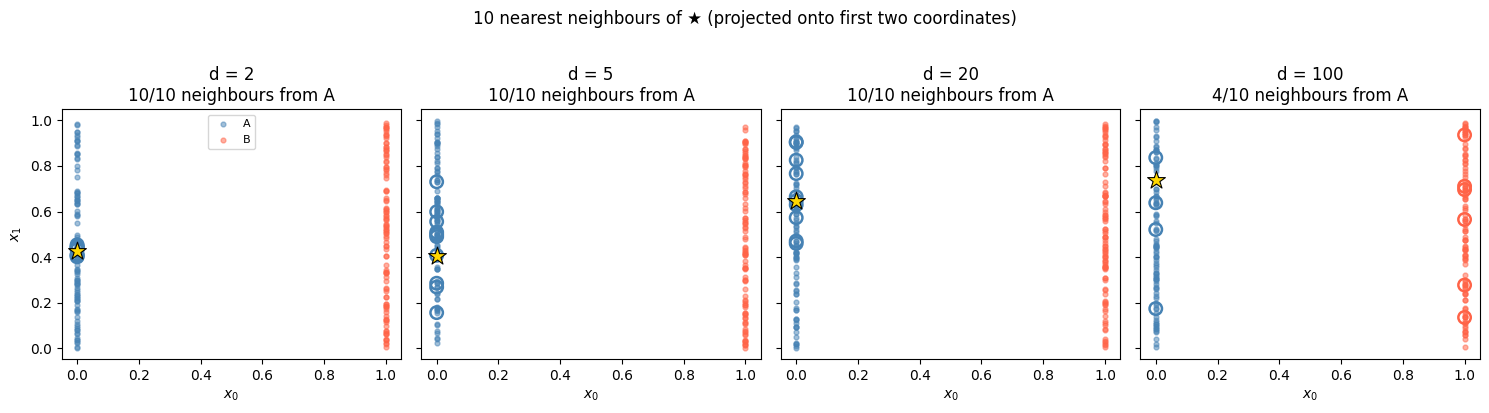

In [5]:
scatter_dims = [2, 5, 20, 100]
query_i      = 30          # which A-point to use as the query
k            = 10

fig, axes = plt.subplots(1, len(scatter_dims), figsize=(15, 4), sharey=True)

for ax, d in zip(axes, scatter_dims):
    A, B   = make_blobs(d)
    X      = np.vstack([A, B])
    labels = np.array([0] * len(A) + [1] * len(B))

    # find 10-NN of the query point in full d-dimensional space
    query       = A[query_i]
    dists       = np.sqrt(((X - query) ** 2).sum(axis=1))
    dists[query_i] = np.inf
    nn_idx      = np.argsort(dists)[:k]
    n_from_A    = (labels[nn_idx] == 0).sum()

    # scatter in (x0, x1) space
    ax.scatter(A[:, 0], A[:, 1], c='steelblue', s=12, alpha=0.5, label='A')
    ax.scatter(B[:, 0], B[:, 1], c='tomato',    s=12, alpha=0.5, label='B')
    # ring the nearest neighbours
    colors = ['steelblue' if labels[i] == 0 else 'tomato' for i in nn_idx]
    ax.scatter(X[nn_idx, 0], X[nn_idx, 1],
               facecolors='none', edgecolors=colors, s=80, linewidths=1.8, zorder=4)
    # mark the query point
    ax.scatter(query[0], query[1], marker='*', s=180, c='gold',
               edgecolors='black', linewidths=0.8, zorder=5)

    ax.set_title(f'd = {d}\n{n_from_A}/10 neighbours from A')
    ax.set_xlabel('$x_0$')

axes[0].set_ylabel('$x_1$')
axes[0].legend(fontsize=8, loc='upper center')
plt.suptitle('10 nearest neighbours of ★ (projected onto first two coordinates)', y=1.02)
plt.tight_layout()
plt.show()

Note that $x_0$ always separates the blobs in the scatter — but the circled neighbours start to come from Blob B as $d$ grows, because in the full high-dimensional space those B-points happen to be close in the other coordinates.

Now let's measure purity systematically across a range of dimensions.

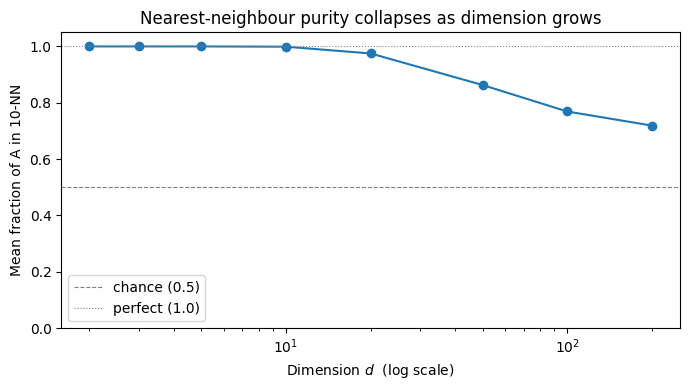

In [6]:
blob_dims  = [2, 3, 5, 10, 20, 50, 100, 200]
purities   = [nn_purity(*make_blobs(d)) for d in blob_dims]

plt.figure(figsize=(7, 4))
plt.plot(blob_dims, purities, 'o-')
plt.xscale('log')
plt.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='chance (0.5)')
plt.axhline(1.0, color='grey', linestyle=':',  linewidth=0.8, label='perfect (1.0)')
plt.xlabel('Dimension $d$  (log scale)')
plt.ylabel('Mean fraction of A in 10-NN')
plt.title('Nearest-neighbour purity collapses as dimension grows')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

In 2 dimensions the blobs are almost perfectly separated and purity is close to 1.  By 200 dimensions it has fallen to near 0.5 — random chance — even though the blobs differ in *every single point* on the $x_0$ coordinate.  The single informative dimension is drowned out by the 199 uninformative ones.

This illustrates why **dimensionality reduction** (Section 1.3) is not just a computational convenience — it can be essential for any method that relies on distance or neighbourhood.